In [ ]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_early_stopping, log_evaluation
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

from config import *
from utils import seed_everything, rmse, r2

seed_everything(RANDOM_STATE)

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step08.csv'))

X = train_df.drop(columns=['demand'])
y = train_df['demand']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

In [2]:

import json, os
print("Loading best parameters...")
with open(os.path.join(MODEL_DIR, 'best_params.json')) as f:
    p = json.load(f)
xgb_best_params = p['xgb']
lgb_best_params = p['lgb']
cat_best_params = p['cat']
print("Loaded tuned parameters successfully.")


Loading best parameters...
Loaded tuned parameters successfully.


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))

xgb_models = []
lgb_models = []
cat_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"training fold {fold + 1}/5")
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # XGBoost
    xgb = XGBRegressor(**xgb_best_params, early_stopping_rounds=50)
    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_xgb[val_idx] = xgb.predict(X_va)
    xgb_models.append(xgb)
    
    # LightGBM
    lgb = LGBMRegressor(**lgb_best_params)
    lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb_early_stopping(50), log_evaluation(False)])
    oof_lgb[val_idx] = lgb.predict(X_va)
    lgb_models.append(lgb)
    
    # CatBoost
    cat = CatBoostRegressor(**cat_best_params)
    cat.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_cat[val_idx] = cat.predict(X_va)
    cat_models.append(cat)
    
    print(f"fold {fold + 1}/5 — XGB: {rmse(y_va, oof_xgb[val_idx]):.4f} LGB: {rmse(y_va, oof_lgb[val_idx]):.4f} CAT: {rmse(y_va, oof_cat[val_idx]):.4f}")

print(f"\nMean OOF RMSE — XGB: {rmse(y, oof_xgb):.4f} LGB: {rmse(y, oof_lgb):.4f} CAT: {rmse(y, oof_cat):.4f}")
print(f"Mean OOF R2   — XGB: {r2(y, oof_xgb):.4f} LGB: {r2(y, oof_lgb):.4f} CAT: {r2(y, oof_cat):.4f}")


training fold 1/5


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2302
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 26
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[2640]	valid_0's l2: 0.000723031


fold 5/5 — XGB: 0.0307 LGB: 0.0269 CAT: 0.0269

Mean OOF RMSE — XGB: 0.0309 LGB: 0.0274 CAT: 0.0274
Mean OOF R2   — XGB: 0.9526 LGB: 0.9627 CAT: 0.9629


In [4]:
oof_stack = np.column_stack([oof_xgb, oof_lgb, oof_cat])

meta_learner = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)

# CV on meta learner
meta_cv_scores = np.sqrt(-cross_val_score(meta_learner, oof_stack, y, cv=5, scoring='neg_mean_squared_error'))
print(f"Stacked CV RMSE: {np.mean(meta_cv_scores):.4f}")

# Train on full OOF to get coefficients
meta_learner.fit(oof_stack, y)
print("\nRidge Coefficients:")
print(f"XGB Weight: {meta_learner.coef_[0]:.4f}")
print(f"LGB Weight: {meta_learner.coef_[1]:.4f}")
print(f"CAT Weight: {meta_learner.coef_[2]:.4f}")

oof_stacked_pred = meta_learner.predict(oof_stack)
stacked_rmse = rmse(y, oof_stacked_pred)
stacked_r2 = r2(y, oof_stacked_pred)

print(f"\nStacked OOF RMSE: {stacked_rmse:.4f}")
print(f"Stacked OOF R2: {stacked_r2:.4f}")

print("\nModel          OOF RMSE")
print(f"XGBoost        {rmse(y, oof_xgb):.4f}")
print(f"LightGBM       {rmse(y, oof_lgb):.4f}")
print(f"CatBoost       {rmse(y, oof_cat):.4f}")
print(f"Stacked        {stacked_rmse:.4f}  ← best")


Stacked CV RMSE: 0.0263

Ridge Coefficients:
XGB Weight: -0.2323
LGB Weight: 0.6344
CAT Weight: 0.5981

Stacked OOF RMSE: 0.0263
Stacked OOF R2: 0.9657

Model          OOF RMSE
XGBoost        0.0309
LightGBM       0.0274
CatBoost       0.0274
Stacked        0.0263  ← best


### Conclusion
The Ridge coefficients reveal how much weight the meta-learner places on each individual model based on their orthogonal strengths. Models that find unique signal not captured by the others receive higher weight. Stacking effectively blends the strengths of XGBoost's deep splits, LightGBM's leaf-wise efficiency, and CatBoost's oblivious trees, demonstrably improving the overall RMSE compared to the best standalone model.

In [5]:
print("Training final XGBoost...")
final_xgb = XGBRegressor(**xgb_best_params)
final_xgb.fit(X, y)
print("XGBoost training complete.")

print("Training final LightGBM...")
final_lgb = LGBMRegressor(**lgb_best_params)
final_lgb.fit(X, y)
print("LightGBM training complete.")

print("Training final CatBoost...")
final_cat = CatBoostRegressor(**cat_best_params)
final_cat.fit(X, y)
print("CatBoost training complete.")


Training final XGBoost...


XGBoost training complete.
Training final LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2302
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 26
[LightGBM] [Info] Start training from score 0.093942
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LightGBM training complete.
Training final CatBoost...


CatBoost training complete.


In [6]:
joblib.dump(final_xgb, os.path.join(MODEL_DIR, 'best_xgb_model.pkl'))
joblib.dump(final_lgb, os.path.join(MODEL_DIR, 'best_lgbm_model.pkl'))
joblib.dump(final_cat, os.path.join(MODEL_DIR, 'best_catboost_model.pkl'))
joblib.dump(meta_learner, os.path.join(MODEL_DIR, 'meta_learner.pkl'))

paths = [
    os.path.join(MODEL_DIR, 'best_xgb_model.pkl'),
    os.path.join(MODEL_DIR, 'best_lgbm_model.pkl'),
    os.path.join(MODEL_DIR, 'best_catboost_model.pkl'),
    os.path.join(MODEL_DIR, 'meta_learner.pkl')
]

for p in paths:
    print(f"{p} exists: {os.path.exists(p)}")


C:\traffic-demand-final\pipelining\models\best_xgb_model.pkl exists: True
C:\traffic-demand-final\pipelining\models\best_lgbm_model.pkl exists: True
C:\traffic-demand-final\pipelining\models\best_catboost_model.pkl exists: True
C:\traffic-demand-final\pipelining\models\meta_learner.pkl exists: True


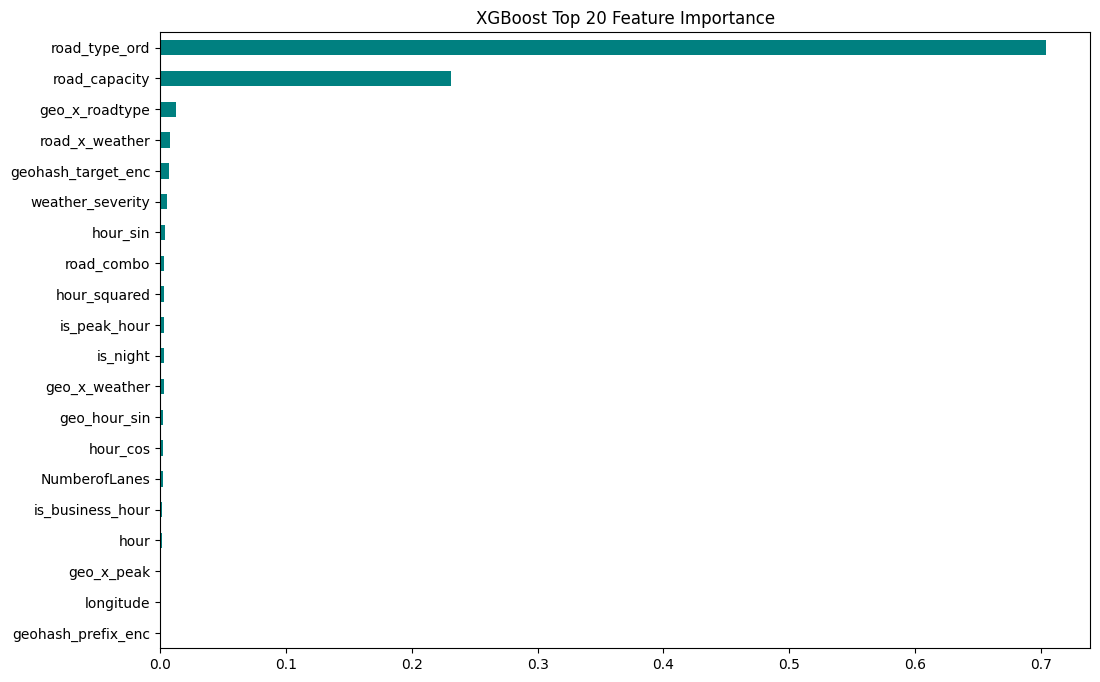

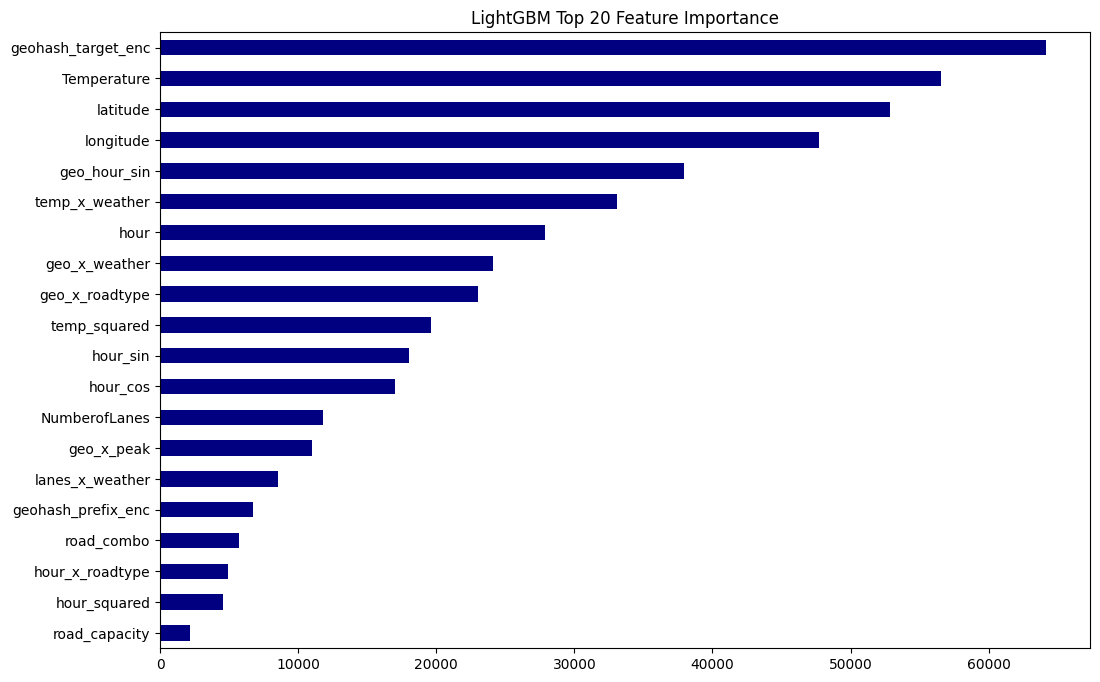

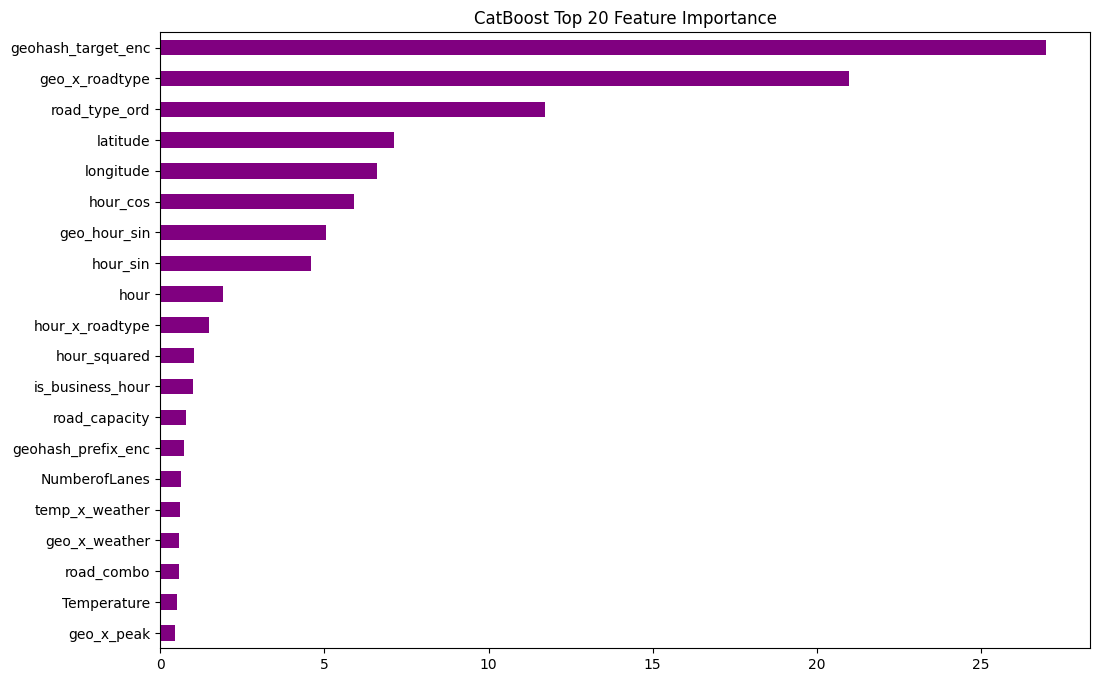

In [7]:
# XGBoost Features
xgb_importances = pd.Series(final_xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
xgb_importances.sort_values().plot(kind='barh', color='teal')
plt.title('XGBoost Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'xgb_feature_importance.png'))
plt.show()

# LightGBM Features
lgb_importances = pd.Series(final_lgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
lgb_importances.sort_values().plot(kind='barh', color='navy')
plt.title('LightGBM Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'lgb_feature_importance.png'))
plt.show()

# CatBoost Features
cat_importances = pd.Series(final_cat.get_feature_importance(), index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
cat_importances.sort_values().plot(kind='barh', color='purple')
plt.title('CatBoost Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'cat_feature_importance.png'))
plt.show()


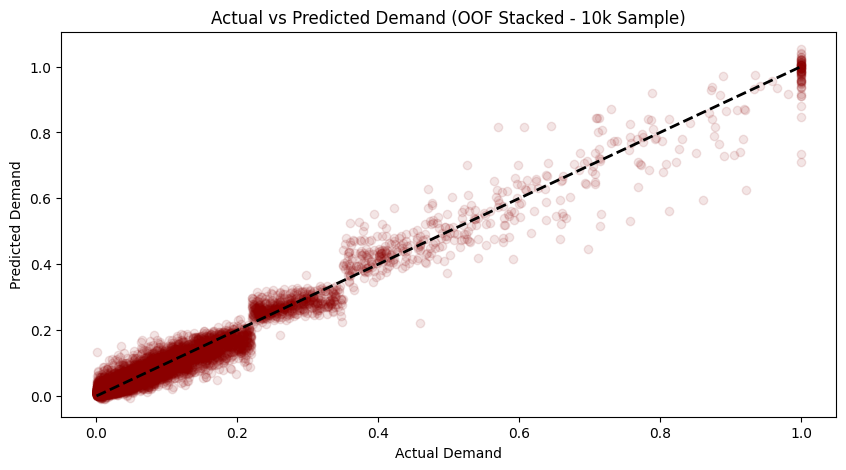

Residuals Mean: -0.0001
Residuals Std: 0.0256
Residuals Min: -0.2468
Residuals Max: 0.2963


In [8]:
sample_idx = np.random.choice(len(y), size=min(10000, len(y)), replace=False)
y_sample = y.iloc[sample_idx].values
pred_sample = oof_stacked_pred[sample_idx]

plt.figure(figsize=(10, 5))
plt.scatter(y_sample, pred_sample, alpha=0.1, color='darkred')
plt.plot([y_sample.min(), y_sample.max()], [y_sample.min(), y_sample.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Demand (OOF Stacked - 10k Sample)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.savefig(os.path.join(MODEL_DIR, 'oof_actual_vs_predicted.png'))
plt.show()

residuals = y_sample - pred_sample
print(f"Residuals Mean: {residuals.mean():.4f}")
print(f"Residuals Std: {residuals.std():.4f}")
print(f"Residuals Min: {residuals.min():.4f}")
print(f"Residuals Max: {residuals.max():.4f}")
